In [1]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [2]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [3]:
compact = True

In [4]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f"data/compacted_{timestamp}.parquet")
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = os.path.join(d, "trash")
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading compacted_20240905102810.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,player_name,player_type,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,
e8471ae6-4685-4fae-903c-bc60a93955dc,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,t,HumanPlayer,call,2,0.3863,0.011589,0,"[3, 0, 0, 0, 0]",172.0,NaN
17ddc421-ed54-4b8e-a543-d8c3f61166f2,e8471ae6-4685-4fae-903c-bc60a93955dc,[],"[96, 91]",0,"[4, 9]","[4, 9]","[True, True]","[False, False]",0,4,t,HumanPlayer,fold,0,0.3863,0.025109,0,"[3, 0, 0, 0, 0]",172.0,NaN
c1a6b9fa-0e54-4a42-be02-9b5dec8cfd3b,None,[],"[92, 96]",0,"[4, 8]","[4, 8]","[False, True]","[False, False]",1,4,t,HumanPlayer,call,4,0.5052,0.030312,0,"[4, 3, 0, 0, 0]",1281.0,NaN
256ec0ab-22bb-443a-8472-9cf8a5a21bbd,c1a6b9fa-0e54-4a42-be02-9b5dec8cfd3b,"[11, 29, 31]","[88, 96]",0,"[0, 0]","[8, 8]","[False, True]","[False, False]",1,4,t,HumanPlayer,raise,8,0.6115,0.048920,1,"[3, 11, 5, 4, 0]",1281.0,NaN
b3b1a507-e05d-402a-b8bf-24586d305db0,256ec0ab-22bb-443a-8472-9cf8a5a21bbd,"[11, 29, 31]","[80, 66]",0,"[8, 30]","[16, 38]","[True, True]","[False, False]",1,4,t,HumanPlayer,call,22,0.6115,0.165105,1,"[3, 11, 5, 4, 0]",1281.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56832d49-3323-4a3c-b61a-d78f1cc32fad,3ca7d536-17db-4180-acb0-f621b7e3c3ee,[],"[88, 100]",0,"[4, 8]","[4, 8]","[True, True]","[False, False]",0,4,Arin,HumanPlayer,raise,10,0.5697,0.034182,0,"[11, 6, 0, 0, 0]",1153.0,NaN
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,56832d49-3323-4a3c-b61a-d78f1cc32fad,"[27, 28, 1]","[78, 94]",0,"[0, 0]","[14, 14]","[False, False]","[False, False]",0,4,Arin,HumanPlayer,raise,30,0.5338,0.074732,1,"[1, 11, 6, 2, 0]",1153.0,NaN
e45b4fdd-5017-45b8-b839-87b08f5c264d,6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,"[27, 28, 1]","[48, 54]",0,"[30, 40]","[44, 54]","[True, True]","[False, False]",0,4,Arin,HumanPlayer,raise,48,0.5338,0.261562,1,"[1, 11, 6, 2, 0]",1153.0,NaN


In [5]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [6]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [7]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,game_id,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,...,opponent_check_river,opponent_check_showdown,action,amount,excess_rank,p,relative_ev,stage,player_name,n_players
e8471ae6-4685-4fae-903c-bc60a93955dc,1515109a-7ac2-497a-82db-af8bbeb6a676,0,0,0,0,0,0,0,0,0,...,0,0,call,2,0,0.3863,0.011589,preflop,t,2
17ddc421-ed54-4b8e-a543-d8c3f61166f2,1515109a-7ac2-497a-82db-af8bbeb6a676,0,0,0,0,0,2,0,0,0,...,0,0,fold,0,0,0.3863,0.025109,preflop,t,2
c1a6b9fa-0e54-4a42-be02-9b5dec8cfd3b,e9cd8b3f-f898-4712-bae4-2178b4535a6e,0,0,0,0,0,0,0,0,0,...,0,0,call,4,0,0.5052,0.030312,preflop,t,2
256ec0ab-22bb-443a-8472-9cf8a5a21bbd,e9cd8b3f-f898-4712-bae4-2178b4535a6e,0,0,0,0,0,4,0,0,0,...,0,0,raise,8,1,0.6115,0.048920,flop,t,2
b3b1a507-e05d-402a-b8bf-24586d305db0,e9cd8b3f-f898-4712-bae4-2178b4535a6e,0,8,0,0,0,4,0,0,0,...,0,0,call,22,1,0.6115,0.165105,flop,t,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56832d49-3323-4a3c-b61a-d78f1cc32fad,b6a995d4-06e0-43c4-8dc9-aedaf7ef0639,0,0,0,0,0,2,0,0,0,...,0,0,raise,10,0,0.5697,0.034182,preflop,Arin,2
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,b6a995d4-06e0-43c4-8dc9-aedaf7ef0639,10,0,0,0,0,2,0,0,0,...,0,0,raise,30,0,0.5338,0.074732,flop,Arin,2
e45b4fdd-5017-45b8-b839-87b08f5c264d,b6a995d4-06e0-43c4-8dc9-aedaf7ef0639,10,30,0,0,0,2,0,0,0,...,0,0,raise,48,0,0.5338,0.261562,flop,Arin,2
d1170aa4-3098-4da3-aa8f-ebaef329d236,b6a995d4-06e0-43c4-8dc9-aedaf7ef0639,10,78,0,0,0,2,0,0,0,...,0,0,check,0,0,0.4246,0.390632,turn,Arin,2


In [8]:
df.dtypes

game_id                     object
raise_preflop                int64
raise_flop                   int64
raise_turn                   int64
raise_river                  int64
raise_showdown               int64
call_preflop                 int64
call_flop                    int64
call_turn                    int64
call_river                   int64
call_showdown                int64
check_preflop                int64
check_flop                   int64
check_turn                   int64
check_river                  int64
check_showdown               int64
opponent_raise_preflop       int64
opponent_raise_flop          int64
opponent_raise_turn          int64
opponent_raise_river         int64
opponent_raise_showdown      int64
opponent_call_preflop        int64
opponent_call_flop           int64
opponent_call_turn           int64
opponent_call_river          int64
opponent_call_showdown       int64
opponent_check_preflop       int64
opponent_check_flop          int64
opponent_check_turn 

## Training

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

In [10]:
X = df.drop(["excess_rank", "game_id", "p", "relative_ev"], axis=1)
y = df["p"]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [11]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,opponent_check_preflop,opponent_check_flop,opponent_check_turn,opponent_check_river,opponent_check_showdown,action,amount,stage,player_name,n_players
e8471ae6-4685-4fae-903c-bc60a93955dc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,call,2,preflop,t,2
17ddc421-ed54-4b8e-a543-d8c3f61166f2,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,fold,0,preflop,t,2
c1a6b9fa-0e54-4a42-be02-9b5dec8cfd3b,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,call,4,preflop,t,2
256ec0ab-22bb-443a-8472-9cf8a5a21bbd,0,0,0,0,0,4,0,0,0,0,...,0,1,0,0,0,raise,8,flop,t,2
b3b1a507-e05d-402a-b8bf-24586d305db0,0,8,0,0,0,4,0,0,0,0,...,0,1,0,0,0,call,22,flop,t,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56832d49-3323-4a3c-b61a-d78f1cc32fad,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,raise,10,preflop,Arin,2
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e,10,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,raise,30,flop,Arin,2
e45b4fdd-5017-45b8-b839-87b08f5c264d,10,30,0,0,0,2,0,0,0,0,...,0,0,0,0,0,raise,48,flop,Arin,2
d1170aa4-3098-4da3-aa8f-ebaef329d236,10,78,0,0,0,2,0,0,0,0,...,0,0,0,0,0,check,0,turn,Arin,2


In [12]:
y

e8471ae6-4685-4fae-903c-bc60a93955dc    0.3863
17ddc421-ed54-4b8e-a543-d8c3f61166f2    0.3863
c1a6b9fa-0e54-4a42-be02-9b5dec8cfd3b    0.5052
256ec0ab-22bb-443a-8472-9cf8a5a21bbd    0.6115
b3b1a507-e05d-402a-b8bf-24586d305db0    0.6115
                                         ...  
56832d49-3323-4a3c-b61a-d78f1cc32fad    0.5697
6573af7b-2d08-4b20-a4c1-2ec5cf5c6c4e    0.5338
e45b4fdd-5017-45b8-b839-87b08f5c264d    0.5338
d1170aa4-3098-4da3-aa8f-ebaef329d236    0.4246
52c554f1-fb2c-41a6-ad56-de73fe010d10    0.2056
Name: p, Length: 4652, dtype: float64

In [13]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = ["action", "stage", "player_name"]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

In [14]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (3719, 35)
Test shape: (933, 35)


In [15]:
# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage',
                                                   'player_name'])])),
                ('regressor', LinearRegression())])

In [16]:
# Get predictions
y_pred = model.predict(X_test)
pred_df = pd.DataFrame({"y_test": y_test, "y_pred": y_pred})
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"MAE: {mae}")
mape = np.mean(np.abs((y_test - y_pred) / y_test))
print(f"MAPE: {mape*100:.2f}%")
pred_df

RMSE: 0.16360640847735888
MAE: 0.12609495127559692
MAPE: 31.80%


,y_test,y_pred
42c73fc3-0b84-4923-9f81-f4a271311214,0.5474,0.500488
8d8ebae1-aefd-4706-a996-17fb073464a7,0.4295,0.502868
340c4564-e421-46fb-b895-f3f214ba722c,0.3383,0.494052
f056091f-24bf-4442-b399-4b345681bf3c,0.3039,0.457629
e33f3e8d-d258-42de-8625-24f410e58a7d,0.4922,0.539113
...,...,...
03375f33-043c-4dbe-9717-875984a8fa0a,0.9514,0.509811
dfe7d46e-7794-480e-b99e-a8e920d172fd,0.3991,0.671239
609515a2-1e27-46f9-9b22-fff7696db1f2,0.3167,0.556697
b7f47436-b127-4195-a08f-53844e0d673c,0.2168,0.547880


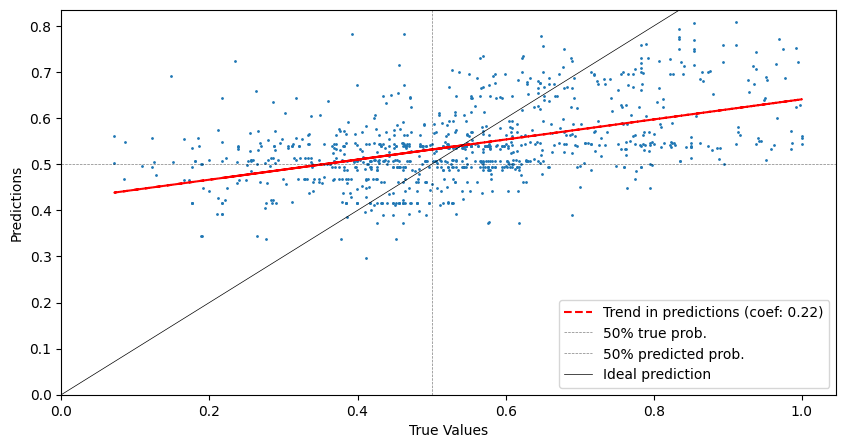

In [31]:
# Plot predictions vs actual
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(y_test, y_pred, s=1)
# Plot a trend line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), "r--", label=f"Trend in predictions (coef: {z[0]:.2f})")
plt.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% true prob.")
plt.axhline(y=0.5, color="black", linestyle="--", alpha=0.5, linewidth=0.5, label="50% predicted prob.")
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100], color="black", linewidth=0.5, label="Ideal prediction")
plt.legend()
plt.show()